# EGX Analyst — Dataset Documentation

This notebook performs the Initial Exploratory Data Analysis (EDA) for a two-layer stock prediction and analysis system. The historical market data spans from **2019-01-01 to Present**, sourced via `yfinance` with split and dividend adjustments applied (`auto_adjust=True`).

---

## 1. Selected EGX Companies

| Ticker | Company Name | Sector / Market Role | Why It Matters |
| :--- | :--- | :--- | :--- |
| **COMI.CA** | Commercial International Bank (CIB) | Banking & Financial Services | The heavy-weight anchor of the EGX30 index; heavily driven by institutional and foreign inflows. |
| **HRHO.CA** | EFG Holding (Hermes) | Investment Banking & Finance | The premier financial services and investment banking powerhouse in the Middle East and Africa. |
| **TMGH.CA** | Talaat Moustafa Group Holding | Real Estate Development | The largest listed real estate developer in Egypt; highly sensitive to urban expansion and macroeconomic hedging. |
| **SWDY.CA** | Elsewedy Electric | Industrials & Infrastructure | A global leader in wires, cables, and turnkey energy infrastructure projects; heavily exposed to industrial growth. |
| **ORWE.CA** | Oriental Weavers | Consumer Goods & Textiles | The world's largest machine-made carpet manufacturer; a massive net-exporter heavily driven by global trade and FX dynamics. |

---

## 2. Market Data Column Definitions

Every stock dataset contains daily trading rows composed of the following core features:

*   **`Date` (Index):** The specific calendar trading day. Used as the timeline index to split data chronologically and eliminate target data leakage.
*   **`Open` (EGP):** The opening match price when trading begins at 10:00 AM. Captures overnight news sentiment and gaps from the previous session's close.
*   **`High` (EGP):** The absolute maximum price at which a transaction occurred during the trading session. Measures daily ceiling resistance.
*   **`Low` (EGP):** The absolute minimum price at which a transaction occurred during the trading session. Measures daily floor support.
*   **`Close` (EGP):** The closing price of the stock. Adjusted dynamically for past cash dividends and stock splits. **This serves as the baseline for calculating our binary next-day price target (UP/DOWN).**
*   **`Volume` (Count):** The total volume of shares traded between buyers and sellers during the day. Acts as the validation of price trend strength (conviction).

# importing necessary libraries

In [13]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [14]:
TICKERS = ["COMI.CA", "HRHO.CA", "TMGH.CA", "SWDY.CA", "ORWE.CA"]  # fixed EKHW → HRHO
START = "2019-01-01"

os.makedirs("../data/raw", exist_ok=True)

for ticker in TICKERS:
    df = yf.download(ticker, start=START, auto_adjust=True)
    
    # Fix MultiIndex columns — flatten to just: Close, High, Low, Open, Volume
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.dropna(inplace=True)
    
    # Remove zero-volume rows (weekends/holidays that sneak in)
    df = df[df["Volume"] > 0]
    
    path = f"../data/raw/{ticker.replace('.', '_')}.csv"
    df.to_csv(path)
    print(f"{ticker}: {len(df)} rows → saved to {path}")

[*********************100%***********************]  1 of 1 completed


COMI.CA: 1757 rows → saved to ../data/raw/COMI_CA.csv


[*********************100%***********************]  1 of 1 completed


HRHO.CA: 1757 rows → saved to ../data/raw/HRHO_CA.csv


[*********************100%***********************]  1 of 1 completed


TMGH.CA: 1761 rows → saved to ../data/raw/TMGH_CA.csv


[*********************100%***********************]  1 of 1 completed


SWDY.CA: 1759 rows → saved to ../data/raw/SWDY_CA.csv


[*********************100%***********************]  1 of 1 completed

ORWE.CA: 1760 rows → saved to ../data/raw/ORWE_CA.csv


# Sanity check all the 5 EGX companies' datasets to ensure they are free of missing values, duplicates, and other anomalies.

In [15]:
# Sanity check all 5 files
for ticker in TICKERS:
    path = f"../data/raw/{ticker.replace('.', '_')}.csv"
    df = pd.read_csv(path, index_col="Date", parse_dates=True)
    print(f"\n{ticker}")
    print(f"  Rows     : {len(df)}")
    print(f"  Date range: {df.index[0].date()} → {df.index[-1].date()}")
    print(f"  Columns  : {list(df.columns)}")
    print(f"  Nulls    : {df.isna().sum().sum()}")
    print(f"  Sample   :\n{df.tail(3)}")


COMI.CA
  Rows     : 1757
  Date range: 2019-01-02 → 2026-06-29
  Columns  : ['Close', 'High', 'Low', 'Open', 'Volume']
  Nulls    : 0
  Sample   :
                 Close        High         Low        Open   Volume
Date                                                               
2026-06-25  132.500000  133.000000  131.949997  132.100006  2284054
2026-06-28  129.820007  133.000000  129.800003  132.500000  1925671
2026-06-29  126.889999  130.300003  126.209999  129.820007  5226945

HRHO.CA
  Rows     : 1757
  Date range: 2019-01-02 → 2026-06-29
  Columns  : ['Close', 'High', 'Low', 'Open', 'Volume']
  Nulls    : 0
  Sample   :
                Close       High    Low       Open    Volume
Date                                                        
2026-06-25  26.860001  27.549999  26.84  27.170000  14170567
2026-06-28  26.400000  27.000000  26.25  26.860001   3415445
2026-06-29  26.520000  26.610001  26.09  26.400000   1762570

TMGH.CA
  Rows     : 1761
  Date range: 2019-01-02 → 202

In [16]:
DATA_DIR = Path("../data/raw")
TICKER_FILES = {ticker: f"{ticker.replace('.', '_')}.csv" for ticker in TICKERS}

stock_data = {}
for ticker, filename in TICKER_FILES.items():
    stock_df = pd.read_csv(DATA_DIR / filename, index_col="Date", parse_dates=True).sort_index()
    stock_df = stock_df.loc[:, ["Close", "High", "Low", "Open", "Volume"]].dropna()
    stock_data[ticker] = stock_df

log_returns = pd.DataFrame(
    {
        ticker: np.log(stock_df["Close"] / stock_df["Close"].shift(1))
        for ticker, stock_df in stock_data.items()
    }
).dropna()

display(log_returns.head())
print(f"Combined daily log returns shape: {log_returns.shape}")

,COMI.CA,HRHO.CA,TMGH.CA,SWDY.CA,ORWE.CA
Date,,,,,
2019-01-03,0.004994,-0.003286,0.008768,-0.013393,0.014666
2019-01-06,0.002749,0.006562,-0.000971,0.000562,0.008156
2019-01-08,-0.012364,0.031544,0.016370,0.032591,0.000000
2019-01-09,-0.014262,0.015718,0.030106,0.000000,-0.002711
2019-01-10,-0.005384,0.009314,0.005545,0.009197,-0.001812


Combined daily log returns shape: (1742, 5)


## Daily Returns, Distributions, and Volatility

,Annualized Volatility
SWDY.CA,0.424281
TMGH.CA,0.413420
ORWE.CA,0.369175
HRHO.CA,0.360872
COMI.CA,0.300816


Annualized volatility, sorted from highest to lowest:
SWDY.CA: 42.43%
TMGH.CA: 41.34%
ORWE.CA: 36.92%
HRHO.CA: 36.09%
COMI.CA: 30.08%


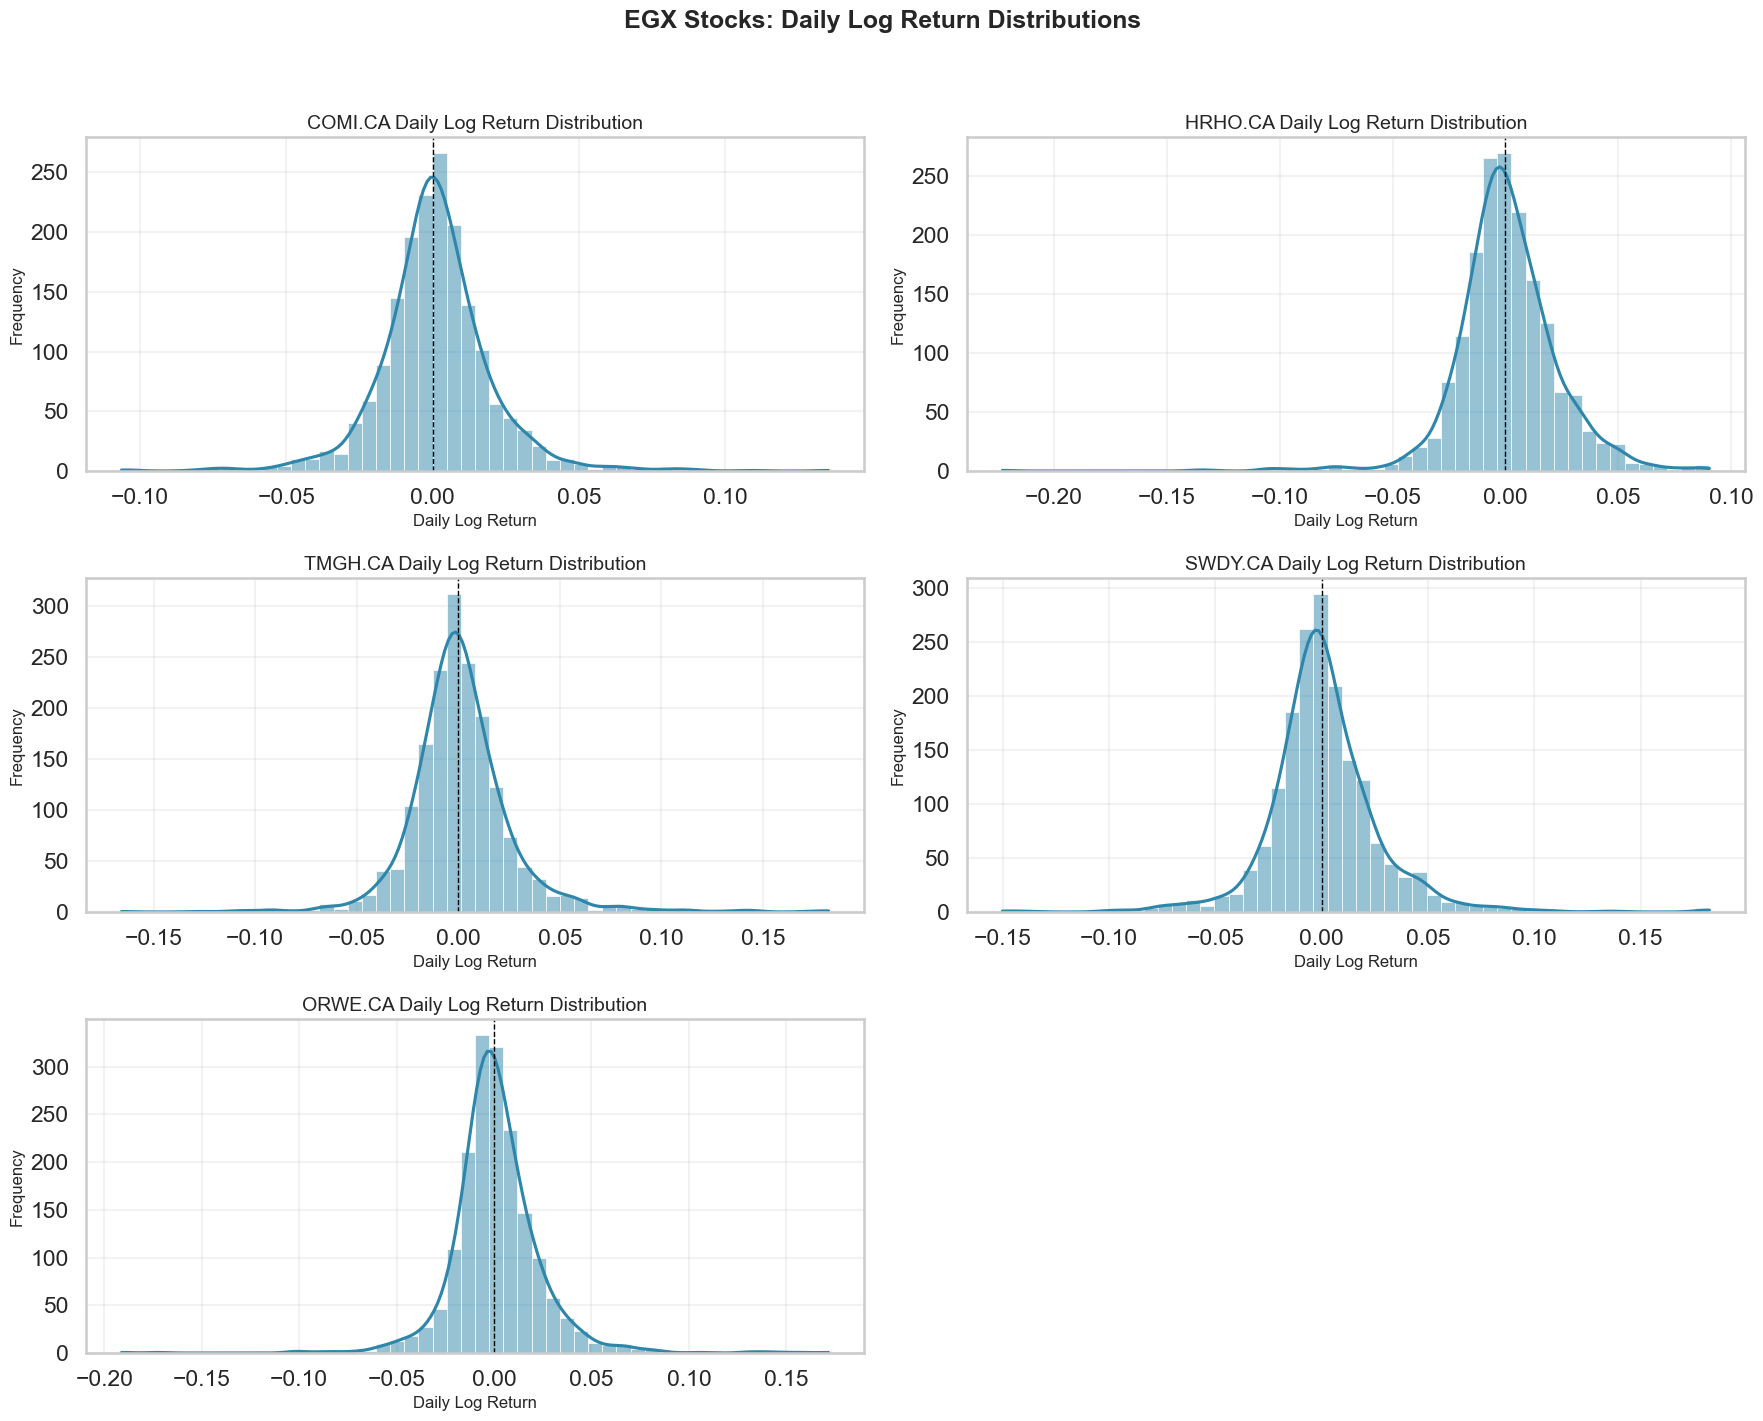

In [17]:
annualized_volatility = log_returns.std() * np.sqrt(252)
volatility_summary = (
    annualized_volatility.sort_values(ascending=False).rename("Annualized Volatility").to_frame()
)

display(volatility_summary)

print("Annualized volatility, sorted from highest to lowest:")
for ticker, volatility in annualized_volatility.sort_values(ascending=False).items():
    print(f"{ticker}: {volatility:.2%}")

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()
hist_color = "#2E86AB"

for index, ticker in enumerate(TICKERS):
    sns.histplot(
        log_returns[ticker],
        bins=50,
        kde=True,
        ax=axes[index],
        color=hist_color,
        edgecolor="white",
        linewidth=0.5,
    )
    axes[index].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[index].set_title(f"{ticker} Daily Log Return Distribution")
    axes[index].set_xlabel("Daily Log Return")
    axes[index].set_ylabel("Frequency")
    axes[index].grid(True, alpha=0.25)

for axis in axes[len(TICKERS):]:
    axis.set_visible(False)

plt.suptitle("EGX Stocks: Daily Log Return Distributions", y=1.02, fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## Correlation Analysis

,COMI.CA,HRHO.CA,TMGH.CA,SWDY.CA,ORWE.CA
COMI.CA,1.000000,0.401072,0.294553,0.345606,0.344501
HRHO.CA,0.401072,1.000000,0.436526,0.439897,0.408582
TMGH.CA,0.294553,0.436526,1.000000,0.441780,0.338221
SWDY.CA,0.345606,0.439897,0.441780,1.000000,0.361415
ORWE.CA,0.344501,0.408582,0.338221,0.361415,1.000000


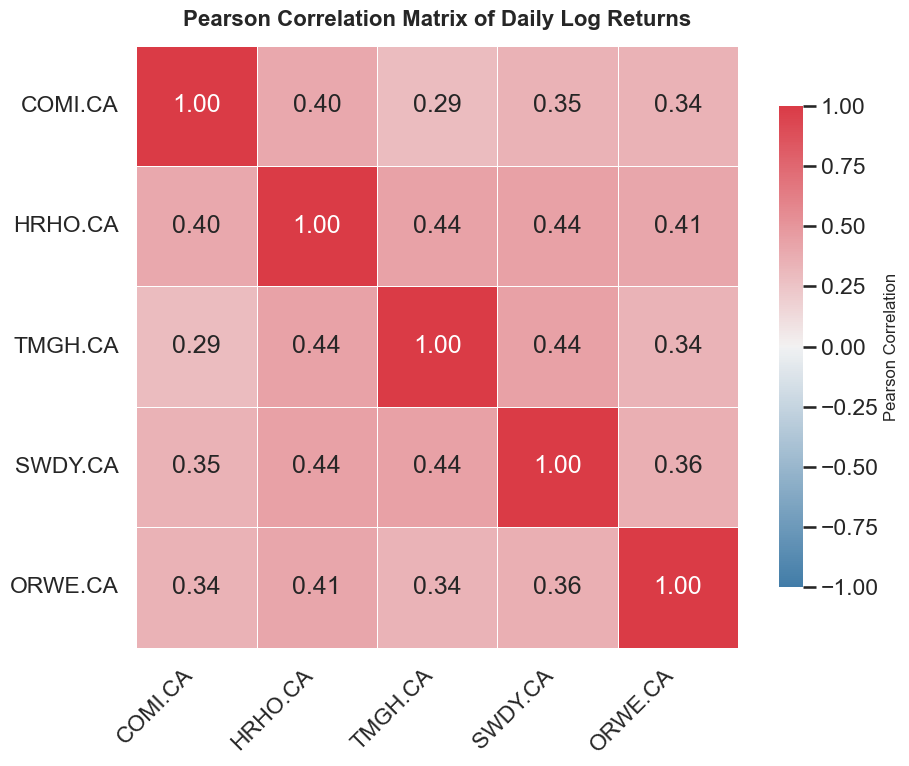

In [18]:
correlation_matrix = log_returns.corr(method="pearson")
display(correlation_matrix)

plt.figure(figsize=(10, 8))
heatmap_cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=heatmap_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)
plt.title("Pearson Correlation Matrix of Daily Log Returns", fontsize=16, fontweight="bold", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Price vs Volume Analysis

In [19]:
def add_volume_spike_features(stock_df, window=21, spike_multiplier=2.5):
    enriched_df = stock_df.copy()
    enriched_df["Daily_Log_Return"] = np.log(enriched_df["Close"] / enriched_df["Close"].shift(1))
    enriched_df["Volume_Rolling_21D"] = enriched_df["Volume"].rolling(window=window, min_periods=window).mean()
    enriched_df["Volume_Spike"] = enriched_df["Volume"] > (spike_multiplier * enriched_df["Volume_Rolling_21D"])
    return enriched_df

volume_analysis = {}
spike_summary_records = []

for ticker, stock_df in stock_data.items():
    enriched_df = add_volume_spike_features(stock_df)
    volume_analysis[ticker] = enriched_df

    spike_mask = enriched_df["Volume_Spike"].fillna(False)
    spike_days = int(spike_mask.sum())
    avg_spike_return = enriched_df.loc[spike_mask, "Daily_Log_Return"].mean()

    spike_summary_records.append(
        {
            "Ticker": ticker,
            "Spike Days": spike_days,
            "Average Return on Spike Days": avg_spike_return,
        }
    )

spike_summary = pd.DataFrame(spike_summary_records).set_index("Ticker")
display(spike_summary)

print("Volume spike summary:")
for ticker, row in spike_summary.iterrows():
    avg_return = row["Average Return on Spike Days"]
    avg_return_text = "N/A" if pd.isna(avg_return) else f"{avg_return:.4%}"
    print(f"{ticker}: {int(row['Spike Days'])} spike days | avg spike-day return = {avg_return_text}")

,Spike Days,Average Return on Spike Days
Ticker,,
COMI.CA,71,-0.003494
HRHO.CA,96,0.015458
TMGH.CA,108,0.020758
SWDY.CA,104,0.019986
ORWE.CA,112,0.015229


Volume spike summary:
COMI.CA: 71 spike days | avg spike-day return = -0.3494%
HRHO.CA: 96 spike days | avg spike-day return = 1.5458%
TMGH.CA: 108 spike days | avg spike-day return = 2.0758%
SWDY.CA: 104 spike days | avg spike-day return = 1.9986%
ORWE.CA: 112 spike days | avg spike-day return = 1.5229%


## EDA Summary and Key Insights

- The combined daily log-return panel provides a clean, aligned view of all 5 EGX stocks and is the right foundation for cross-asset analysis.
- The return histograms show how each ticker’s return distribution differs in spread and tail behavior, which is a practical proxy for relative risk and event sensitivity.
- Annualized volatility is the fastest way to compare risk across the basket; the highest-volatility name should be treated as the most aggressive asset in the group.
- The Pearson correlation matrix highlights whether the stocks move together or diversify one another. Higher positive correlations imply weaker diversification benefits.
- The 21-day rolling volume spike filter identifies unusually active sessions and helps isolate days where price discovery likely had stronger conviction.
- Comparing spike-day returns against the full sample can reveal whether heavy participation tends to confirm trend continuation or cluster around reversal-type events.
- Taken together, this notebook suggests a workflow for distinguishing high-risk, high-activity names from more stable stocks and for using volume confirmation as a secondary signal in modeling and trading research.